In [ ]:
!pip install pymfe

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from time import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import cross_validate, StratifiedKFold, LeaveOneOut
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, f1_score

from pymfe.mfe import MFE

## Passo 1: Obter conjunto de datasets de treinamento

In [ ]:
#Carregando os datasets
from sklearn.datasets import fetch_openml

names = ['diabetes', 'blood-transfusion-service-center',
         'monks-problems-2', 'tic-tac-toe', 'titanic', 'pc1',
         'kr-vs-kp', 'phoneme', 'wdbc', 'semeion', 'isolet',
         'cnae-9', 'ilpd-numeric', 'students_scores',
         'usps', 'ibm-employee-performance','mushroom',
         'segment',  'autoUniv-au1-1000', 'pizzacutter3',
         'qsar', 'solar-flare']

#Errors: 'sick-numeric', 'telco-custumer-churn', 'credit-g', 'anneal'
#Too big: 'kits'

datasets = {}
for name in names:
    print('Fetching dataset: {}'.format(name))
    datasets[name] = fetch_openml(name=name, as_frame=True)

print(f'Finished fetching {len(datasets)} datasets.')


## Passo 2: Avaliar performance dos classificadores nos datasets

In [ ]:
# Define classifiers
from sklearn.impute import SimpleImputer


classifiers = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'Perceptron': Perceptron(random_state=42, max_iter=1000),
    'MLP': MLPClassifier(random_state=42, max_iter=1000)
}

# Store results
results = []

# Iterate through datasets
for dataset_name in names:
    print(f'Processing dataset: {dataset_name}')

    # Get data and target
    X = datasets[dataset_name]['data']
    y = datasets[dataset_name]['target']

    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        print(f'Warning: Imputation failed for {dataset_name} with error: {e}')
        print('Falling back to simple imputation strategy.')
        # Use most frequent strategy for string/categorical data
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        # Fit and transform the data
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


    # Handle categorical features
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    # Encode target if necessary
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)

    # Evaluate each classifier
    for clf_name, clf in classifiers.items():
        print(f'  Evaluating {clf_name}...', end=' ')

        # 5-fold cross validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_results = cross_validate(clf, X, y, cv=cv, scoring='accuracy',
                                    return_train_score=False)

        # Extract fold accuracies
        fold_accs = cv_results['test_score']

        # Create result row
        result_row = {
            'Dataset': dataset_name,
            'Classifier': clf_name,
            'acc_fold1': fold_accs[0],
            'acc_fold2': fold_accs[1],
            'acc_fold3': fold_accs[2],
            'acc_fold4': fold_accs[3],
            'acc_fold5': fold_accs[4],
            'acc_mean': fold_accs.mean(),
            'acc_stddev': fold_accs.std(),
            'train_time': cv_results['fit_time'].sum(),
            'test_time': cv_results['score_time'].sum()
        }

        results.append(result_row)
        print('Done')

# Create results DataFrame
performances_df = pd.DataFrame(results)

In [ ]:
# Saving results to CSV
performances_df.to_csv('classifier_performances.csv', index=False)

In [ ]:
# Loading results from CSV
performances_df = pd.read_csv('classifier_performances.csv')


In [ ]:
performances_df

## Passo 3: Extrair meta-features dos datasets

In [ ]:
# Extract meta-features
meta_features = []

for dataset_name in names:
    print(f'Extracting meta-features from {dataset_name}...', end=' ')

    # Get data and target
    X = datasets[dataset_name]['data']
    y = datasets[dataset_name]['target']

    # Handle categorical features
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    # Encode target if necessary
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        # Convert to numpy array if it's a pandas Series
        y = np.array(y)

    # Extract meta-features
    try:
        mfe = MFE(groups=["general", "statistical", "info-theory",
                          "clustering", #"concept", "model_based", "landmarking", "complexity",
                          ], summary='mean')
        mfe.fit(X.values, y)
        ft = mfe.extract()

        # Create result row with dataset name and meta-features
        result_row = {'dataset': dataset_name}

        meta_features.append(pd.DataFrame(dict(zip(ft[0], ft[1])), index=[dataset_name]))
        print('Done')
    except Exception as e:
        print(f'Error: {e}')

# Create meta-features DataFrame
meta_features_df = pd.concat(meta_features, ignore_index=False)

In [ ]:
# Saving meta-features to CSV
meta_features_df.to_csv('dataset_meta_features.csv', index=True)

In [ ]:
# Loading meta-features from CSV
meta_features_df = pd.read_csv('dataset_meta_features.csv', index_col=0)

In [ ]:
meta_features_df

# Passo 4: Combinar as meta-features e as performances

In [ ]:
performances_df

In [ ]:
# Reshape performances_df to have one row per dataset and the performance (acc_mean) of each classifier as a separate column
performances_df2 = performances_df.pivot(index='Dataset', columns='Classifier', values='acc_mean')
performances_df2.columns.name = None
performances_df2 = performances_df2.reset_index()
performances_df2

In [ ]:
# Merge performances_df2 with meta_features_df based on dataset name
meta_dataset = performances_df2.merge(
    right=meta_features_df,
    left_on='Dataset',
    right_index=True,
    how='left'
)

# Reorder columns: 'Dataset' first, then meta-features, then classifiers
meta_cols = meta_features_df.columns.tolist()
classifier_cols = performances_df2.columns.drop('Dataset').tolist()
meta_dataset = meta_dataset[['Dataset'] + meta_cols + classifier_cols]

In [ ]:
meta_dataset

In [ ]:
# Get the classifier columns (last 6 columns)
classifier_cols = meta_dataset.columns[-6:].tolist()

# Find the classifier with the best (maximum) accuracy for each dataset
meta_dataset['Best'] = meta_dataset[classifier_cols].idxmax(axis=1)

In [ ]:
meta_dataset

In [ ]:
pd.DataFrame(meta_dataset['Best'].value_counts())

# Passo 5: Treinar (e avaliar) o meta-modelo

In [ ]:
meta_dataset.replace([np.inf, -np.inf], np.nan, inplace=True)

# Create a dictionary to store the reuslts:
summary_of_predictions = {'Dataset':[], 'Best clf (true)':[], 'Perf of best clf (true)':[],
                           'Best clf (pred)':[], 'Perf of best clf (pred)':[]}

loo = LeaveOneOut()
feat_import_perf_fold = []
y_true = meta_dataset['Best'].values
y_pred = []

for train_index, test_index in loo.split(meta_dataset):
    # Split the data into training and test sets
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols) # Drop everything except meta-features
    y = meta_dataset['Best']
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train a simple classifier (e.g., Decision Tree) on the training set
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    # Predict the best classifier for the test dataset
    y_pred.append(clf.predict(X_test)[0])

    # Store results in the summary dictionary
    summary_of_predictions['Dataset'].append(meta_dataset['Dataset'].iloc[test_index].values[0])
    summary_of_predictions['Best clf (true)'].append(y_test.values[0])
    summary_of_predictions['Perf of best clf (true)'].append(meta_dataset.loc[test_index, y_test.values[0]].values[0])
    summary_of_predictions['Best clf (pred)'].append(y_pred[-1])
    summary_of_predictions['Perf of best clf (pred)'].append(meta_dataset.loc[test_index, y_pred[-1]].values[0])


# Create a DataFrame from the summary of predictions
summary_df = pd.DataFrame(summary_of_predictions)

# Calculate meta-model accuracy and F1-score
meta_model_accuracy = accuracy_score(y_true, y_pred)
meta_model_f1 = f1_score(y_true, y_pred, average='weighted')
print(f'Meta-model Accuracy: {meta_model_accuracy:.2f}')
print(f'Meta-model F1-score: {meta_model_f1:.2f}')


In [ ]:
summary_df

In [ ]:
# Base-level performance:
summary_df.describe()


In [ ]:
final_summary = pd.concat([performances_df2, summary_df], axis=1)
# Drop second 'Dataset' column
idx_to_drop = list(final_summary.columns).index('Dataset', 1)  # Find the index of the second 'Dataset' column
final_summary = final_summary.drop(columns=final_summary.columns[idx_to_drop], axis=1)
final_summary

In [ ]:
final_summary.boxplot(rot=90)

## Exercício
---

Caso não queria executar a parte de cima por demorar um pouco, pode iniciar a partir da celula de importação.

In [ ]:
!pip install pymfe

In [ ]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from pymfe.mfe import MFE
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

### Tentando melhorar acuracia
---
Primeiramente vamos carregar os dados do csv para caso execute dessa célula para baixo, adicione os arquivos csv `classifier_performances` e `dataset_meta_features`


In [ ]:
df_perf_old = pd.read_csv('classifier_performances.csv')
df_meta_old = pd.read_csv('dataset_meta_features.csv', index_col=0)
idx_best_old = df_perf_old.groupby('Dataset')['acc_mean'].idxmax()
best_clf_old = df_perf_old.loc[idx_best_old, ['Dataset', 'Classifier', 'acc_mean']].set_index('Dataset')

Para o experimento vamos adicionar 3 novos datasets: iris, wine e glass.

In [ ]:
novos_datasets = ['iris', 'wine', 'glass']
base_classifiers = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'LR': LogisticRegression(max_iter=500, random_state=42),
    'MLP': MLPClassifier(max_iter=500, random_state=42)
}

novas_meta_features = []
nova_performance = []

for d_name in novos_datasets:
    data = fetch_openml(name=d_name, version=1, as_frame=True, parser='auto')
    X = data.data.select_dtypes(include=np.number).fillna(0)
    y = LabelEncoder().fit_transform(data.target)

    mfe = MFE(groups=["general", "statistical", "info-theory"])
    mfe.fit(X.values, y)
    ft_names, ft_values = mfe.extract()

    meta_dict = dict(zip(ft_names, ft_values))
    meta_dict['Dataset'] = d_name
    novas_meta_features.append(meta_dict)

    for clf_name, clf in base_classifiers.items():
        acc_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
        nova_performance.append({
            'Dataset': d_name,
            'Classifier': clf_name,
            'acc_mean': np.mean(acc_scores)
        })

df_meta_new = pd.DataFrame(novas_meta_features).set_index('Dataset')
df_perf_new = pd.DataFrame(nova_performance)
idx_best_new = df_perf_new.groupby('Dataset')['acc_mean'].idxmax()
best_clf_new = df_perf_new.loc[idx_best_new, ['Dataset', 'Classifier', 'acc_mean']].set_index('Dataset')

In [ ]:
#Combinando os valores
X_meta_all = pd.concat([df_meta_old, df_meta_new], axis=0).astype(float)
y_meta_all = pd.concat([best_clf_old['Classifier'], best_clf_new['Classifier']])

df_perf_all = pd.concat([df_perf_old, df_perf_new], axis=0)
def get_base_acc(dataset, clf_name):
    val = df_perf_all[(df_perf_all['Dataset'] == dataset) & (df_perf_all['Classifier'] == clf_name)]['acc_mean']
    return val.values[0] if len(val) > 0 else 0.0

Agora é preciso combinar os dados antigos com os novos, ou seja, concatenar ambos os datasets para fazer o pipeline. Com isso, na busca de melhorar a performance média de nível base em termos de acurácia haverá 3 pipelines:

1. O antigo com apenas pré-processamento básico e árvore de deciso simples, com a estragia sendo a média
2. Modificar apenas o pré-processamento para mediana, usando `StandardScaler` para normalização e seleção com `SelectKBest`
3. Na última será utilizado o mesmo pre-processamento do item 2, porém com o `Random Forest`

In [ ]:

pipelines = {
    "V1": Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),

    "V2": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('fs', SelectKBest(score_func=f_classif, k=15)),
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),

    "V3": Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('fs', SelectKBest(score_func=f_classif, k=15)),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
}

In [ ]:
loo = LeaveOneOut()
resultados = []

print("Avaliando os meta-modelos:\n")

cenarios = [
    ("V1: Baseline", pipelines["V1"], df_meta_old, best_clf_old['Classifier']),
    ("V2: Novo Pre-proc", pipelines["V2"], df_meta_old, best_clf_old['Classifier']),
    ("V3: Novo Meta-Modelo (RF)", pipelines["V3"], df_meta_old, best_clf_old['Classifier']),
    ("V4: V3 + Novos Datasets Reais", pipelines["V3"], X_meta_all, y_meta_all)
]

for nome_versao, pipeline, X_data, y_data in cenarios:
    meta_y_true = []
    meta_y_pred = []
    base_accuracies = []

    X_data = X_data.loc[y_data.index]
    X_data = X_data.replace([np.inf, -np.inf], np.nan) # Evitar o erro divisão por 0

    for train_index, test_index in loo.split(X_data):
        X_train, X_test = X_data.iloc[train_index], X_data.iloc[test_index]
        y_train, y_test = y_data.iloc[train_index], y_data.iloc[test_index]
        dataset_name = X_data.index[test_index[0]]

        pipeline.fit(X_train, y_train)

        pred = pipeline.predict(X_test)[0]


        meta_y_true.append(y_test.values[0])
        meta_y_pred.append(pred)

        base_acc = get_base_acc(dataset_name, pred)
        base_accuracies.append(base_acc)

    acc_meta = accuracy_score(meta_y_true, meta_y_pred)
    acc_base_media = np.mean(base_accuracies)

    resultados.append({
        "Estratégia": nome_versao,
        "Acurácia Meta (%)": round(acc_meta * 100, 2),
        "Acurácia Média Base (%)": round(acc_base_media * 100, 2)
    })

#### Resultados
---

Nessa seção pode demorar um pouco para executar

In [ ]:
df_resultados = pd.DataFrame(resultados)
print("TABELA DE RESULTADOS: EVOLUÇÃO DO META-APRENDIZADO")
display(df_resultados)

Veja que acurácia só melhorou na estrategia do pipeline V2, porém vamos buscar novos dados para verificar quais algoritmos desempenharam melhor...

In [ ]:
from sklearn.datasets import fetch_openml

names = ['diabetes', 'blood-transfusion-service-center',
         'monks-problems-2', 'tic-tac-toe', 'titanic', 'pc1',
         'kr-vs-kp', 'phoneme', 'wdbc', 'semeion', 'isolet',
         'cnae-9', 'ilpd-numeric', 'students_scores',
         'usps', 'ibm-employee-performance','mushroom',
         'segment',  'autoUniv-au1-1000', 'pizzacutter3',
         'qsar', 'solar-flare']

#Errors: 'sick-numeric', 'telco-custumer-churn', 'credit-g', 'anneal'
#Too big: 'kits'

datasets = {}
for name in names:
    print('Fetching dataset: {}'.format(name))
    datasets[name] = fetch_openml(name=name, as_frame=True)

print(f'Finished fetching {len(datasets)} datasets.')

In [ ]:
novos_datasets = ['iris', 'wine', 'glass']

print("Baixando novos datasets para adicionar ao experimento...")

for d_name in novos_datasets:
    if d_name in names:
        continue

    data = fetch_openml(name=d_name, version=1, as_frame=True, parser='auto')

    names.append(d_name)

    datasets[d_name] = {
        'data': data.data,
        'target': data.target
    }
    print(f"Dataset '{d_name}' adicionado com sucesso!")

print("-" * 50)
meta_features = []

for dataset_name in names:
    print(f'Extracting meta-features from {dataset_name}...', end=' ')

    X = datasets[dataset_name]['data']
    y = datasets[dataset_name]['target']

    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        y = np.array(y)

    try:
        mfe = MFE(groups=["general", "statistical", "info-theory",
                          "clustering", #"concept", "model_based", "landmarking", "complexity",
                          ], summary='mean')
        mfe.fit(X.values, y)
        ft = mfe.extract()

        result_row = {'dataset': dataset_name}

        meta_features.append(pd.DataFrame(dict(zip(ft[0], ft[1])), index=[dataset_name]))
        print('Done')
    except Exception as e:
        print(f'Error: {e}')

meta_features_df = pd.concat(meta_features, ignore_index=False)

In [ ]:
pd.set_option('display.max_columns', None)
display(meta_features_df)

In [ ]:
df_apenas_novos = df_perf_all[df_perf_all['Dataset'].isin(novos_datasets)]

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.boxplot(data=df_apenas_novos, x='Classifier', y='acc_mean', color='lightblue')
ordem_x = [tick.get_text() for tick in ax.get_xticklabels()]
medianas = df_apenas_novos.groupby('Classifier')['acc_mean'].median().reindex(ordem_x)
ax.plot(range(len(medianas)), medianas, color='red', marker='o', linestyle='-', linewidth=2, zorder=3)

sns.stripplot(data=df_apenas_novos, x='Classifier', y='acc_mean', color='black', alpha=0.6, jitter=True)

plt.title('Distribuição da Acurácia: (Iris, Wine, Glass)', fontsize=14, pad=15)
plt.xlabel('Algoritmo', fontsize=12)
plt.ylabel('Acurácia Média', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")


ax = sns.boxplot(data=df_perf_old, x='Classifier', y='acc_mean', color='lightblue')


ordem_x = [tick.get_text() for tick in ax.get_xticklabels()]


medianas = df_perf_old.groupby('Classifier')['acc_mean'].median().reindex(ordem_x)


ax.plot(range(len(medianas)), medianas, color='black', marker='o', linestyle='-', linewidth=2, zorder=3)


plt.title('Distribuição da Acurácia dos Classificadores Base', fontsize=14, pad=15)
plt.xlabel('Algoritmo', fontsize=12)
plt.ylabel('Acurácia Média', fontsize=12)

plt.tight_layout()
plt.show()

Veja que não modificou muito o gráfico `Distribuição da Acurácia dos Classificadores Base`, entretando, os melhores algoritmos (segundo o grafico `Distribuição da Acurácia: (Iris, Wine, Glass)`) para 3 novos datasets
seria a regressão logista e a rede neural Perceptron Multicamadas


## Exercício 2
---

Para o inicio dessa atividade basta executar as células abaixo

In [ ]:
!pip install pymfe

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, wilcoxon
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

## Parte 1
---

In [ ]:
#Talvez use isso retire isso
df_performance = pd.read_csv('classifier_performances.csv')
df_meta_features = pd.read_csv('dataset_meta_features.csv', index_col=0)

In [ ]:
#Talvez use isso retire isso
print(df_performance.columns)

In [ ]:
#Talvez use isso retire isso
print(df_performance["Classifier"].unique())

In [ ]:
df_performance.head(10)

In [ ]:
df_y = df_performance.pivot_table(index='Dataset', columns='Classifier', values='acc_mean')
df_y_reset = df_y.reset_index()

In [ ]:
meta_dataset = pd.merge(df_meta_features, df_y_reset, left_index=True, right_on='Dataset')
display(meta_dataset.head(22))

In [ ]:
colunas_y = df_y.columns.tolist()
Y = meta_dataset[colunas_y]
X = meta_dataset.drop(columns=['Dataset'] + colunas_y)
X = X.select_dtypes(exclude=['object', 'string'])
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)


meta_model = RandomForestRegressor(n_estimators=100, random_state=42)
Y_pred_all = cross_val_predict(meta_model, X, Y, cv=cv_strategy)
df_pred_all = pd.DataFrame(Y_pred_all, columns=colunas_y, index=meta_dataset['Dataset'])

display(df_pred_all)

In [ ]:
df_rankings_all = df_pred_all.rank(axis=1, ascending=False, method='min')
display(df_rankings_all)

### Parte 2
---

In [ ]:
colunas_y = df_y.columns.tolist()
Y_notas = meta_dataset[colunas_y]

X = meta_dataset.drop(columns=['Dataset'] + colunas_y)
X = X.select_dtypes(exclude=['object', 'string'])

Y_rankings_reais = Y_notas.rank(axis=1, ascending=False, method='min')

print("RANKINGS REAIS (Nosso novo alvo de aprendizado)")
display(Y_rankings_reais.head(22))

In [ ]:
meta_model_rank = RandomForestRegressor(n_estimators=100, random_state=42)

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

Y_pred_raw = cross_val_predict(meta_model_rank, X, Y_rankings_reais, cv=cv_strategy)

df_pred_raw = pd.DataFrame(Y_pred_raw, columns=colunas_y, index=meta_dataset['Dataset'])

print("PREVISÕES BRUTAS DO MODELO (Números contínuos)")
display(df_pred_raw.head(22))

In [ ]:
df_rankings_finais = df_pred_raw.rank(axis=1, ascending=True, method='min')

print("RANKING FINAL RECOMENDADO")
display(df_rankings_finais.head(22))

#### A)
---

In [ ]:
Y_notas.index = meta_dataset['Dataset']
X.index = meta_dataset['Dataset']

Y_melhor_algo_real = Y_notas.idxmax(axis=1)

clf_meta_modelo = RandomForestClassifier(n_estimators=100, random_state=42)
previsoes_a3 = cross_val_predict(clf_meta_modelo, X, Y_melhor_algo_real, cv=cv_strategy)
previsoes_a3 = pd.Series(previsoes_a3, index=X.index)

def pegar_nota_real_do_recomendado(df_rankings_preditos, Y_notas_reais):
    melhores_algoritmos = df_rankings_preditos.idxmin(axis=1)
    notas_obtidas = [Y_notas_reais.loc[dataset, algo] for dataset, algo in melhores_algoritmos.items()]
    return pd.Series(notas_obtidas, index=melhores_algoritmos.index)


notas_a1 = pegar_nota_real_do_recomendado(df_rankings_all, Y_notas)

notas_a2 = pegar_nota_real_do_recomendado(df_rankings_finais, Y_notas)

notas_a3 = pd.Series([Y_notas.loc[dataset, algo] for dataset, algo in previsoes_a3.items()], index=X.index)

notas_ideais = Y_notas.max(axis=1)

df_comparacao = pd.DataFrame({
    'Abordagem 1': notas_a1,
    'Abordagem 2': notas_a2,
    'Abordagem do exemplo': notas_a3,
    'Cenário Ideal': notas_ideais
})

print("### NOTAS REAIS OBTIDAS POR CADA ESTRATÉGIA (Amostra) ###")
display(df_comparacao.head(22))


In [ ]:
count_a1 = (notas_a1 == notas_ideais).sum()
count_a2 = (notas_a2 == notas_ideais).sum()
count_a3 = (notas_a3 == notas_ideais).sum()

plt.bar(["Abordagem 1", "Abordagem 2", "Abordagem do exemplo"], [count_a1, count_a2, count_a3])
plt.show()

In [ ]:
print("### MÉDIA DE PERFORMANCE ###")
resumo_medias = df_comparacao.mean().sort_values(ascending=False)
display(resumo_medias.to_frame(name='Acurácia Média Final'))

Veja que mesmo utilizando uma abordagem diferente de predizer performances ainda não foi possível chegar no caso dos algoritmos com a melhor acurácia. Mas, existe um cenário melhor que na abordagem do exemplo (best algoritmo). Só que no gráfico mostra que abordagem 2 foi que teve mais valores iguais ao cenário ideal (modelo base), assim mostrando que converter performances em rankings e depois predizer os rankings seja uma abordagem mais eficiente para esse cenário dos 22 datasets.

#### B)
---


In [ ]:
nomes_datasets = meta_dataset["Dataset"].values
Y_rankings_reais.index = nomes_datasets
df_rankings_all.index = nomes_datasets
df_rankings_finais.index = nomes_datasets

src_a1 = []
src_a2 = []

datasets = Y_rankings_reais.index

for dataset in datasets:
    ranking_real = Y_rankings_reais.loc[dataset]
    ranking_predito_a1 = df_rankings_all.loc[dataset]
    ranking_predito_a2 = df_rankings_finais.loc[dataset]

    corr_a1, _ = spearmanr(ranking_real, ranking_predito_a1)
    corr_a2, _ = spearmanr(ranking_real, ranking_predito_a2)

    src_a1.append(corr_a1)
    src_a2.append(corr_a2)

df_src = pd.DataFrame({
    'Dataset': datasets,
    'Prever Notas': src_a1,
    'Prever Ranking': src_a2
}).set_index('Dataset')

print("### CORRELAÇÃO DE SPEARMAN (SRC) POR DATASET ###")
display(df_src.head(22))

In [ ]:
media_src_a1 = np.mean(src_a1)
media_src_a2 = np.mean(src_a2)

print("### MÉDIA DE QUALIDADE DOS RANKINGS (NÍVEL META) ###")
print(f"Média Abordagem 1: {media_src_a1:.4f}")
print(f"Média Abordagem 2:   {media_src_a2:.4f}")

if media_src_a1 > media_src_a2:
    print("VENCEDOR NO NÍVEL META: Abordagem 1")
elif media_src_a2 > media_src_a1:
    print("\nVENCEDOR NO NÍVEL META: Abordagem 2")
else:
    print("\nEMPATE TÉCNICO no nível meta!")

Como o SRC tem objetivo de verificar a fila inteira do raking em relação as predições reais com as predições do meta modelo, o mesmo consegue ser mais preciso que outras metricas, pois ele não está preocupado com os números da acurácias dos modelos e sim na ordem que eles ficaram. A formula do SRC:
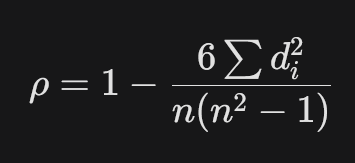

* ρ (rho): É o resultado final do SRC [entre -1 e 1].
* di: É a diferença de posição (ranking) de um mesmo algoritmo entre a lista * real e a lista prevista.
* n: É a quantidade total de algoritmos sendo avaliados.
* 6: É uma constante fixa da fórmula de Spearman.

Assim, mostrando mais uma vez que abordagem 2 tem uma melhor performance que abordagem 1, com isso, ao prever rakings nesse cenário de 22 datasets será mais acertivo que prever acurácia (nota) dos modelos.

### C)
---

In [ ]:
stat, p_value = wilcoxon(src_a1, src_a2)

print("### RESULTADO DO TESTE DE HIPÓTESE ESTATÍSTICO ###")
print(f"Estatística do Teste (W): {stat:.4f}")
print(f"Valor-p (p-value):        {p_value:.4f}")

alpha = 0.05

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(src_a1, src_a2, color='#a569bd', s=80, alpha=0.9, edgecolor='white')

min_val = min(min(src_a1), min(src_a2)) - 0.1
max_val = max(max(src_a1), max(src_a2)) + 0.1
ax.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', label='Linha de Empate (A1 = A2)')

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_aspect('equal')

ax.set_title('Confronto Direto por Dataset', fontsize=14)
ax.set_xlabel('SRC - Abordagem 1', fontsize=12)
ax.set_ylabel('SRC - Abordagem 2', fontsize=12)

significativo = "Diferença Significativa" if p_value < alpha else "Empate Técnico (Não Signif.)"

texto_stats = (
    f"Teste de Wilcoxon\n"
    f"------------------------\n"
    f"Estatística (W): {stat:.2f}\n"
    f"Valor-p: {p_value:.4f}\n"
    f"{significativo}"
)

props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='lightgray')

ax.text(0.05, 0.95, texto_stats, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props, fontweight='bold')

ax.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

Como o p-value (0.0989) é maior ou igual ao alpha (0.05), não é possivel rejeitar a Hipótese Nula (H0). Assim, não há diferença estatisticamente significativa entre as duas abordagens.
Isso significa que as variações no SRC não teve efeito significaticativo, pois ao escolher qualquer uma das duas abordagens para o seu sistema final haverá uma perda performance de formance insignificante, talvez a perda seja apenas na distribuição do ranking e caso queria apenas os melhores ambos conseguir objetivos parecidos.


## Exercício 4
---

Pode iniciar a partir da célula abaixo a execução

In [1]:
# usando outro ambiente
!uv pip install pymfe

Using Python 3.13.3 environment at: C:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv
Checked 1 package in 195ms


In [ ]:
!pip install pymfe

In [8]:
import openml
from sklearn.datasets import fetch_openml
from pathlib import Path

### A)
---

In [4]:
df_datasets = openml.datasets.list_datasets(output_format="dataframe")
df_datasets["Area"] = df_datasets["NumberOfClasses"] * df_datasets["NumberOfFeatures"]
df_datasets = df_datasets[  (df_datasets["NumberOfInstancesWithMissingValues"] == 0) &
                            (df_datasets["Area"] > 300) & 
                            (df_datasets["Area"] < 50000) &
                            (df_datasets["NumberOfFeatures"] > 10) &
                            (df_datasets["NumberOfFeatures"] < 100) &
                            (df_datasets["NumberOfInstances"] > 800) &
                            (df_datasets["NumberOfInstances"] < 20000)]
df_datasets.head(5)

,did,name,version,uploader,status,format,MajorityClassSize,MaxNominalAttDistinctValues,MinorityClassSize,NumberOfClasses,NumberOfFeatures,NumberOfInstances,NumberOfInstancesWithMissingValues,NumberOfMissingValues,NumberOfNumericFeatures,NumberOfSymbolicFeatures,Area
14,14,mfeat-fourier,1,1,active,ARFF,200.0,10.0,200.0,10.0,77.0,2000.0,0.0,0.0,76.0,1.0,770.0
16,16,mfeat-karhunen,1,1,active,ARFF,200.0,10.0,200.0,10.0,65.0,2000.0,0.0,0.0,64.0,1.0,650.0
22,22,mfeat-zernike,1,1,active,ARFF,200.0,10.0,200.0,10.0,48.0,2000.0,0.0,0.0,47.0,1.0,480.0
28,28,optdigits,1,1,active,ARFF,572.0,10.0,554.0,10.0,65.0,5620.0,0.0,0.0,64.0,1.0,650.0
1466,1466,cardiotocography,1,64,active,ARFF,579.0,10.0,53.0,10.0,36.0,2126.0,0.0,0.0,35.0,1.0,360.0


In [5]:
print("Número de datasets: ", len(df_datasets))

Número de datasets:  44


In [12]:
datasets = {}

for _, df in df_datasets.iterrows():
    name = df["name"]
    id = df["did"]
    
    datasets[name] = fetch_openml(data_id=id, as_frame=True)
    datasets[name] = datasets[name].frame

In [13]:
print("Tamanho dicionário datasets: ", len(datasets))

Tamanho dicionário datasets:  38


In [15]:
path = Path("datasets")
path.mkdir(exist_ok=True)

for name, data in datasets.items():
    data.to_csv(f"{str(path)}/{name}.csv", index=False)